In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv('amz_uk_price_prediction_dataset.csv')
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [3]:
# PARTE 1
# 1. Crosstab Analysis
# - Create a crosstab between the product `category` and the `isBestSeller` status. 

crosstab = pd.crosstab(df['category'], df['isBestSeller'])

crosstab

isBestSeller,False,True
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3
...,...,...
Wind Instruments,243,7
Window Treatments,234,5
Women,17559,213


La tabla cruzada entre la categoría del producto y su estado de best-seller muestra una primera tabla de números brutos es decir, cuenta cuántos productos hay en cada combinación. 

Por en la categoría Arts & Craft:
- False = nos dice cúantos productos de Arts no son best seller, en este caso, 9319.
- True = nos dice cúantos productos de Arts sí son best seller, en este caso, 230.

In [4]:
# - Are there categories where being a best-seller is more prevalent?

proporcion_bestseller = pd.crosstab(df['category'], df['isBestSeller'], normalize='index')*100
proporcion_bestseller = proporcion_bestseller.sort_values(True, ascending=False).round(2)

proporcion_bestseller

isBestSeller,False,True
category,,
Grocery,94.19,5.81
Smart Home Security & Lighting,94.23,5.77
Health & Personal Care,94.23,5.77
Mobile Phone Accessories,95.75,4.25
Power & Hand Tools,96.47,3.53
...,...,...
"CD, Disc & Tape Players",100.00,0.00
General Music-Making Accessories,100.00,0.00
Snowboard Boots,100.00,0.00


Los porcentajes proporcionales dentro de cada categoría muestran que: 

- True → % de productos de esa categoría que SÍ son best-seller
- False → % de productos de esa categoría que NO son best-seller

Y siempre suman 100% entre los dos. Por ejemplo Grocery:

- 5.81% son best-sellers
- 94.19% no son best-sellers
- 5.81 + 94.19 = 100% 

Respondiendo a la pregunta, las categorías donde ser best-seller es más común son Grocery (5.81%), Smart Home Security (5.77%) y Health & Personal Care (5.77%).

Sin embargo, en todas las categorías el porcentaje de best-sellers es muy bajo porque el máximo es solo 5.81%. Esto indica que ser best-seller es poco común 
independientemente de la categoría.

In [5]:
# 2. Statistical Tests
#   - Conduct a Chi-square test to determine if the best-seller distribution is independent of the product category

chi2, chi2_p_value, _, _ = stats.chi2_contingency(crosstab)

print(f"Chi-cuadrado: {chi2:.2f}")
print(f"P-valor:      {chi2_p_value:.10f}")

Chi-cuadrado: 36540.20
P-valor:      0.0000000000


Chi-cuadrado: 36,540.20 número enorme — hay una diferencia muy grande entre lo que ocurre realmente y lo que pasaría si fuera aleatorio.

P-valor: 0.0000000000 Prácticamente cero — muy por debajo de 0.05. Esto significa que la categoría SÍ influye en ser best-seller, no es casualidad.
El p-valor es tan pequeño que Python ni siquiera puede mostrarlo con 10 decimales.


El 36,540 es la medida de "qué tan diferente es la realidad de lo aleatorio". Es decir:

- Si fuera 0 → todo es aleatorio, la categoría no influye para nada
- Cuanto más grande → más diferencia hay entre lo real y lo aleatorio

El 36.540 es un número gigante, lo que nos dice que hay una diferencia enorme entre lo que ocurre realmente y lo que pasaría si las categorías no influyeran en ser best-seller. Pero por sí solo el 36.540 no nos dice mucho y por eso se necesita el p-valor para saber si esa diferencia es estadísticamente significativa o podría ser casualidad. Y el p-valor de 0.00 confirma que no es casualidad.

En resumen: el chi-cuadrado mide la diferencia, el p-valor nos dice si esa diferencia importa. Recordatorio:
- p-value < 0.05 → la categoría SÍ influye en ser best-seller
- p-value > 0.05 → es casualidad, no hay relación

In [6]:
# - Compute Cramér's V to understand the strength of association between best-seller status and category

from scipy.stats.contingency import association

cramers_v = association(crosstab, method="cramer")

print(f"Cramér's V: {cramers_v:.4f}")

Cramér's V: 0.1223


Resultado de Cramér's V: 0.1223 — relación débil.

Recordatorio de valores:

- 0 → ninguna relación
- 0.1 → relación débil ← estamos aquí
- 0.3 → relación moderada
- 0.5+ → relación fuerte

Insight. Entonces combinando Chi-square y Cramér's V la conclusión es:

- Chi-square → la relación existe y no es casualidad (p-valor = 0)
- Cramér's V → pero esa relación es débil (0.12)

Es decir, la categoría sí influye en ser best-seller, pero no de forma muy fuerte. Hay otros factores que probablemente influyen más.

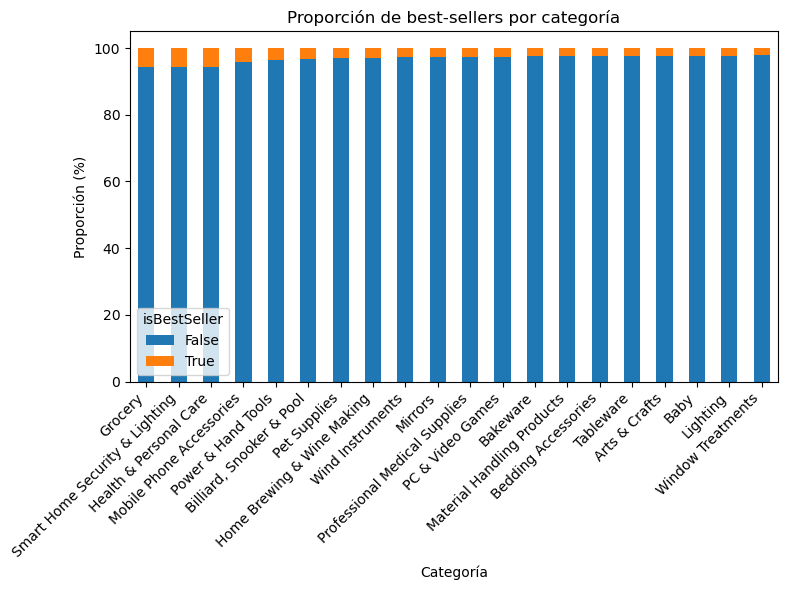

In [7]:
# 3. Visualization
#   - Visualize the relationship between product categories and the best-seller status using a stacked bar chart

proporcion_bestseller.head(20).plot(kind='bar', stacked=True, figsize=(8, 6))
plt.title('Proporción de best-sellers por categoría')
plt.xlabel('Categoría')
plt.ylabel('Proporción (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Insights:
- Cada barra llega al 100% dividida en azul y naranja
- la parte naranja (best sellers)es muy pequeña en todas categorías
- **'Grocery', 'Smart Home Sec' & 'Health'** tienen la parte naranja más grande (aunque en pequeña proporción visualemente)

In [8]:
# PARTE 2
# 0. Preliminary Step: Remove outliers in product prices

# Primero visualizamos los números así entiendo mejor lo que hago
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Límite inferior: {limite_inferior:.2f}")
print(f"Límite superior: {limite_superior:.2f}")


Q1: 9.99
Q3: 45.99
IQR: 36.00
Límite inferior: -44.01
Límite superior: 99.99


In [9]:
# Luego aplicamos función del notebook de clase para eliminar outliers

def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    df_sin_outliers = df[(df[column] >= limite_inferior) & (df[column] <= limite_superior)]
    
    return df_sin_outliers

df_sin_outliers = remove_outliers_iqr(df, 'price')

print(f"Filas originales:    {df.shape[0]}")
print(f"Filas sin outliers:  {df_sin_outliers.shape[0]}")
print(f"Outliers eliminados: {df.shape[0] - df_sin_outliers.shape[0]}")

Filas originales:    2443651
Filas sin outliers:  2115963
Outliers eliminados: 327688


Insights:


- **Q1: £9.99** → el 25% de productos más baratos cuestan menos de £9.99
- **Q3: £45.99** → el 75% de productos cuestan menos de £45.99
- **IQR: £36** → el 50% central de productos está en un rango de £36
- **Límite inferior: -£44.01** → ningún producto tiene precio negativo, así que no se elimina nada por abajo
- **Límite superior: £99.99** → todo producto por encima de £99.99 es outlier
- **327,688 outliers eliminados** → productos con precio mayor de £99.99

Nos quedamos con 2.115,963 productos para el resto del análisis.

/var/folders/vq/dm0z_g7d7gnc_rx3fbh36mtm0000gn/T/ipykernel_3622/2050273623.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_top20, x='category', y='price', palette="coolwarm")


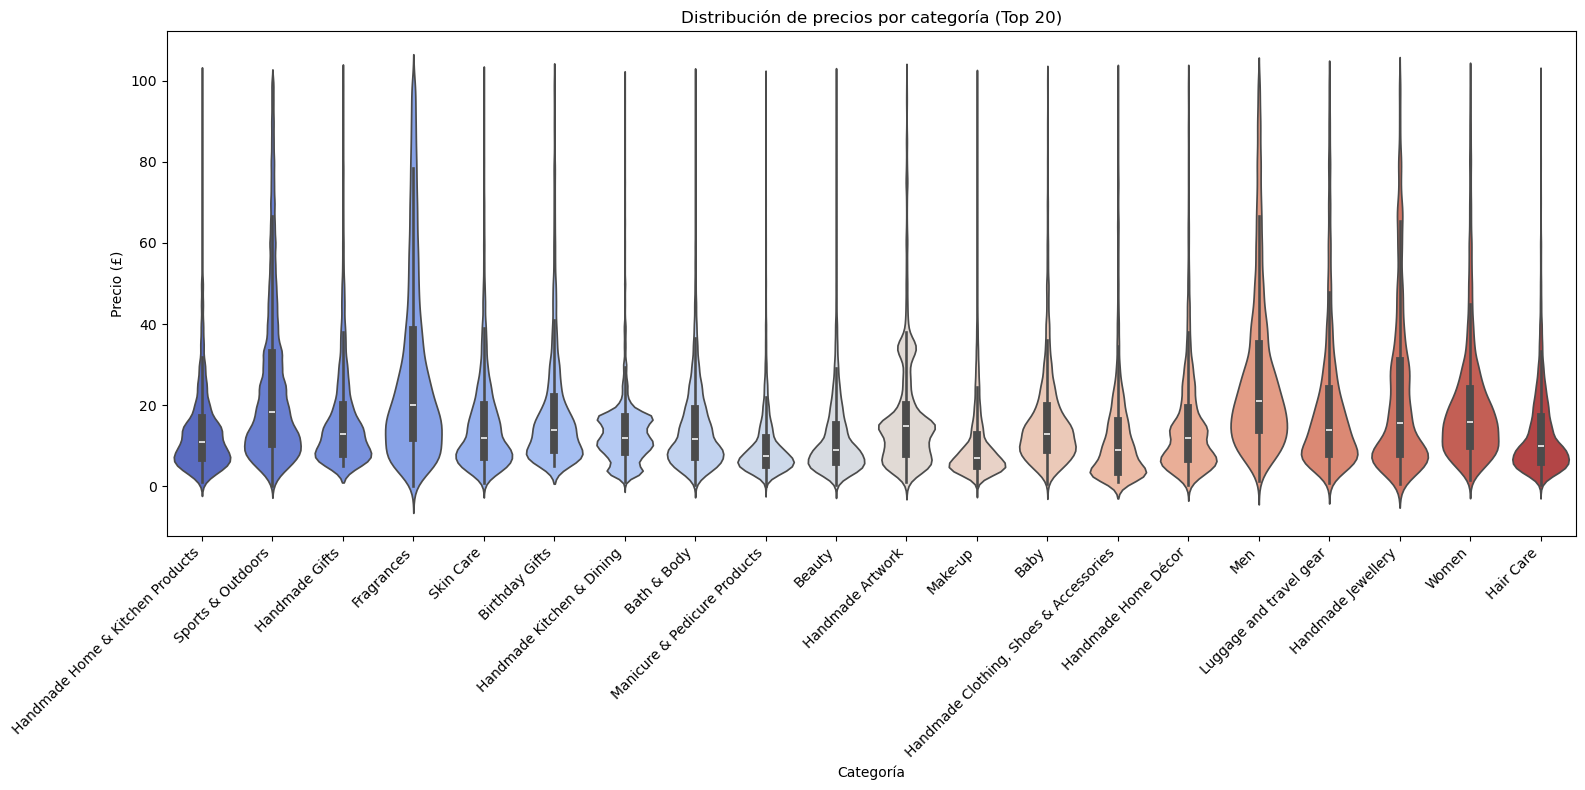

In [10]:
# 1. Violin Plots

# top 20 cat
top20_categorias = df_sin_outliers['category'].value_counts().head(20).index
df_top20 = df_sin_outliers[df_sin_outliers['category'].isin(top20_categorias)]

# violin plot

plt.figure(figsize=(16, 8))
sns.violinplot(data=df_top20, x='category', y='price', palette="coolwarm")
plt.title('Distribución de precios por categoría (Top 20)')
plt.xlabel('Categoría')
plt.ylabel('Precio (£)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

De forma general se puede decir que:
- Todos los violines tienen la parte más ancha cerca de £0-£20 — confirma que la mayoría de productos son baratos en todas las categorías
- Todos tienen cola hacia arriba hasta ~£100 — hay productos más caros en todas las categorías pero son pocos-

Respecto a las categorías:
- Fragrances tiene el violín más ancho en precios medios (~£20-£40) — productos más caros que el resto
- Handmade Artwork también tiene el violín más ancho en precios más altos
- Manicure & Pedicure y Bath & Body tienen violines muy estrechos y pegados al suelo — productos muy baratos y concentrados

El punto blanco en el centro de cada violín es la mediana.


In [11]:
# - Which product category tends to have the highest median price? Don't filter here by top categories

mediana_por_categoria = df_sin_outliers.groupby('category')['price'].median().sort_values(ascending=False)

mediana_por_categoria.head(10)

category
Desktop PCs               74.00
Boxing Shoes              69.79
Tablets                   69.00
Graphics Cards            68.54
Motherboards              67.92
Made in Italy Handmade    64.00
Digital Frames            63.90
Streaming Clients         62.68
Golf Shoes                62.39
Ski Helmets               61.33
Name: price, dtype: float64

Desktop PCs es la categoría con la mediana de precio más alta £74, seguida de Boxing Shoes (£69.79) y Tablets (£69)

Estas categorias no aparecen en el violin plot porque no están en el top 20 por número de productos, hay pocas unidades listadas pero son caras. Por eso el enunciado pedía hacer las dos cosas por separado.

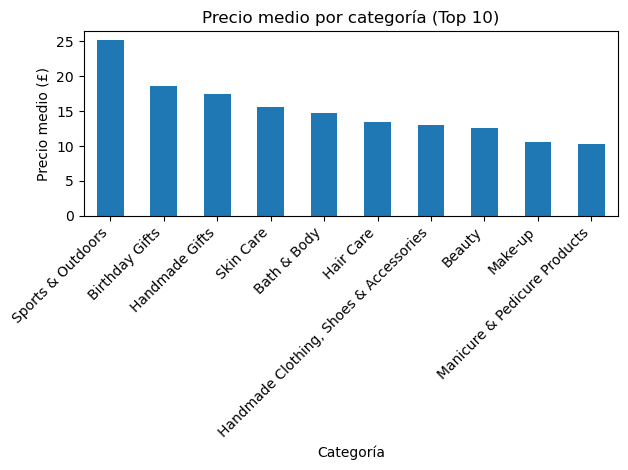

In [12]:
# 2. Bar Charts
# - Create a bar chart comparing the average price of products for the top 10 product categories (based on count).

top10_categorias = df_sin_outliers['category'].value_counts().head(10).index

# Precio medio por categoría
precio_medio = df_sin_outliers[df_sin_outliers['category'].isin(top10_categorias)].groupby('category')['price'].mean().sort_values(ascending=False)


precio_medio.plot(kind='bar')
plt.title('Precio medio por categoría (Top 10)')
plt.xlabel('Categoría')
plt.ylabel('Precio medio (£)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [13]:
# - Which product category commands the highest average price? Don't filter here by top categories

precio_medio_todas = df_sin_outliers.groupby('category')['price'].mean().sort_values(ascending=False)
precio_medio_todas.head(10)

category
Motherboards         68.772432
Boxing Shoes         67.417803
Desktop PCs          66.915562
Tablets              66.552971
Graphics Cards       65.103509
Digital Frames       60.745129
Streaming Clients    60.241803
Hockey Shoes         60.094796
Computer Cases       58.339884
Skiing Poles         57.867770
Name: price, dtype: float64

**Bar chart — Top 10 categorías por número de productos:**

Sports & Outdoors tiene el precio medio más alto (25) del top 10

Manicure & Pedicure Products el más bajo (10)

En general los precios medios están entre 10 y 25 — rango bastante estrecho

**Sin filtrar — categoría con precio medio más alto:**

Motherboards lidera con 68.77 de media

Seguida de Boxing Shoes 67.42 y Desktop PCs (66.92)


De nuevo estas categorías no aparecen en el bar chart porque tienen pocos productos listados pero son caros.

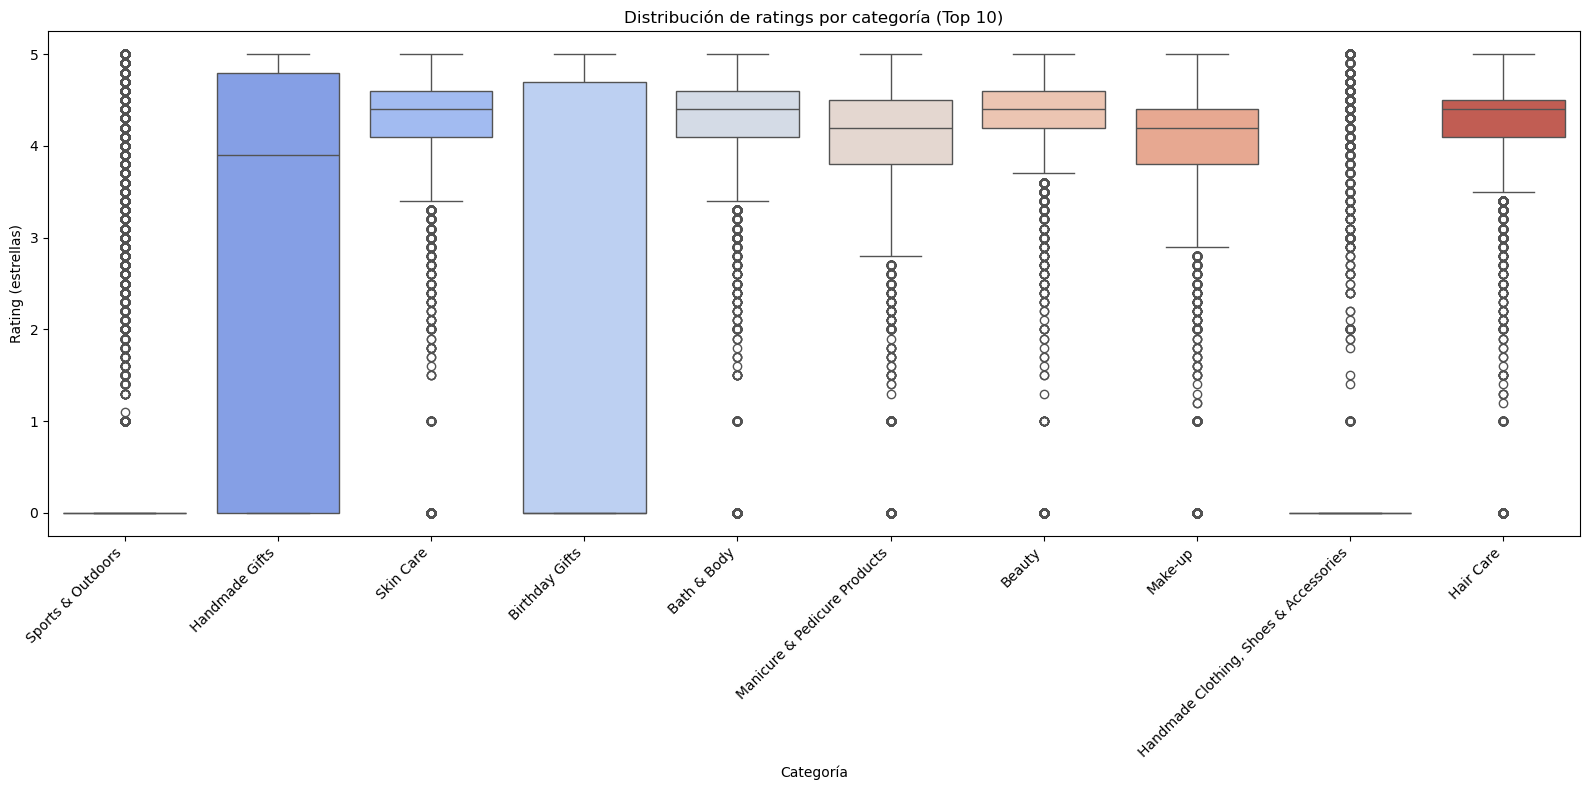

In [18]:
# 3. Box Plots 
# - Visualize the distribution of product `ratings` based on their `category` using side-by-side box plots. Filter out the top 10 categories based on count for better visualization.
top10_categorias = df_sin_outliers['category'].value_counts().head(10).index
df_top10 = df_sin_outliers[df_sin_outliers['category'].isin(top10_categorias)]

# box plot
plt.figure(figsize=(16, 8))
sns.boxplot(data=df_top10, x='category', y='stars', hue='category', palette="coolwarm", legend=False)
plt.title('Distribución de ratings por categoría (Top 10)')
plt.xlabel('Categoría')
plt.ylabel('Rating (estrellas)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [17]:
# - Which category tends to receive the highest median rating from customers? Don't filter here by top categories
mediana_rating = df_sin_outliers.groupby('category')['stars'].median().sort_values(ascending=False)
mediana_rating.head(10)

category
Computer Memory                 4.7
Building & Construction Toys    4.6
Office Paper Products           4.6
Luxury Food & Drink             4.6
Kids' Play Figures              4.6
Hobbies                         4.6
Beer, Wine & Spirits            4.6
Laptop Accessories              4.6
Cables & Accessories            4.5
CPUs                            4.5
Name: stars, dtype: float64

**Box plot — Top 10 categorías por número de productos:**

- La mayoría de categorías (Skin Care, Beauty, Hair Care, Bath & Body, Make-up) concentran sus ratings entre 4 y 4.6, con outliers por debajo (productos con mala nota real)
- Sports & Outdoors y Handmade Clothing tienen la caja aplastada en 0, la mayoría de sus productos tienen stars = 0
- Handmade Gifts y Birthday Gifts tienen cajas enormes (de 0 a 4.7), mezcla de productos sin valorar y bien valorados

El 0 no significa "valoración de cero estrellas", sino producto sin reseñas todavía. No es que la gente odie esos productos, es que aún nadie los ha puntuado. Esto distorsiona las medianas de esas categorías.

Respecto **categoría con la mediana de rating más alta (sin filtrar)**, Computer Memory lidera con 4.7, seguida de un grupo empatado en 4.6 (Building & Construction Toys, Office Paper, Luxury Food & Drink, etc.). Igual que con el precio, estas categorías no aparecen en el box plot porque tienen pocos productos pero bien valorados.

In [ ]:
# PARTE 3
# 1. Correlation Coefficients
# - Calculate the correlation coefficient between `price` and `stars`.
correlacion = df_sin_outliers['price'].corr(df_sin_outliers['stars'])

print(f"Correlación price vs stars: {correlacion:.4f}")

Correlación price vs stars: -0.0777


**- Is there a significant correlation between product price and its rating?**
La correlación es prácticamente nula. El signo negativo indicaría que a más precio, ligeramente menos estrellas, pero el valor es tan pequeño (< 0.1) que en la práctica no hay relación: precio y valoración son independientes.

**Insight:** un producto no recibe mejor nota por ser más caro ni peor por ser barato. Subir el precio no penaliza automáticamente las reseñas.

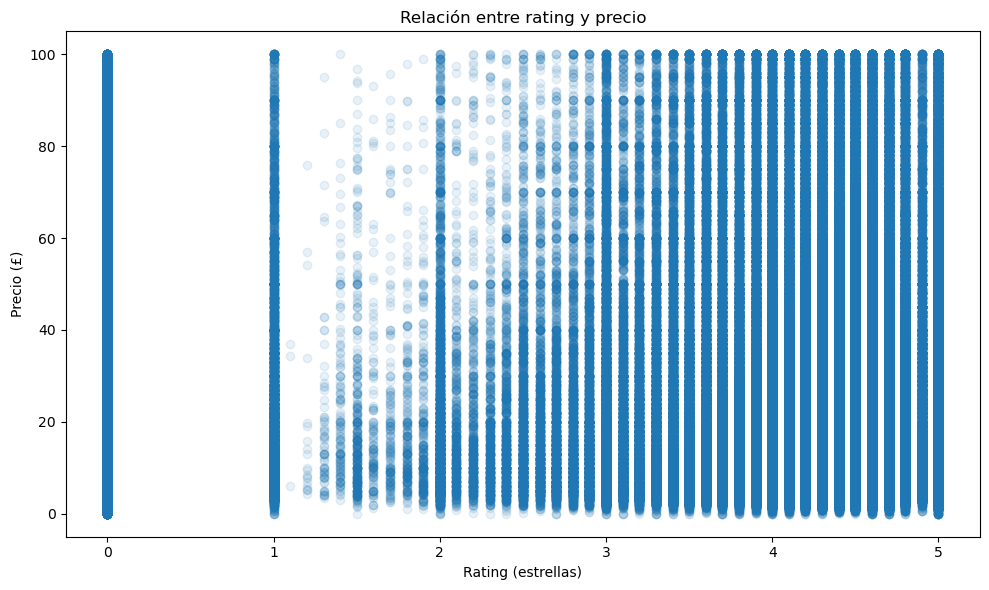

In [20]:
# 2. Visualizations
# - Use a scatter plot to visualize the relationship between product rating and price. What patterns can you observe?
plt.figure(figsize=(10, 6))
plt.scatter(df_sin_outliers['stars'], df_sin_outliers['price'], alpha=0.1)
plt.title('Relación entre rating y precio')
plt.xlabel('Rating (estrellas)')
plt.ylabel('Precio (£)')
plt.tight_layout()
plt.show()

**Scatter plot rating vs precio:**

Los puntos forman líneas verticales (stars va de 0.1 en 0.1, no es continuo), no una nube diagonal. En cada nota los precios van de £0 a £100 sin ninguna tendencia por lo que confirma visualmente la correlación nula.

- La franja densa en stars = 0 son productos sin reseña
- Las columnas entre 4 y 5 son las más saturadas → la mayoría de productos valorados se concentran ahí
- Hueco entre 0 y 1: un producto o tiene reseñas (mín. 1) o no tiene ninguna (0), no hay punto medio

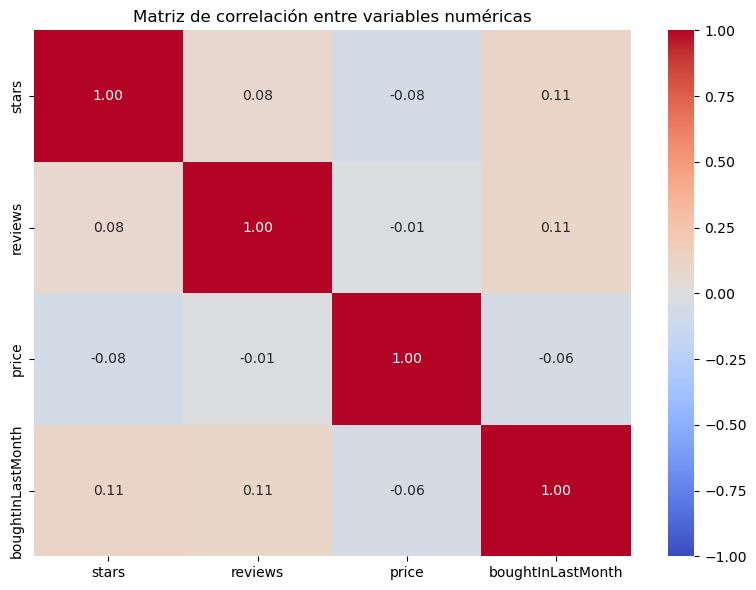

In [21]:
# - Use a correlation heatmap to visualize correlations between all numerical variables.
columnas_num = ['stars', 'reviews', 'price', 'boughtInLastMonth']
matriz_corr = df_sin_outliers[columnas_num].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Matriz de correlación entre variables numéricas')
plt.tight_layout()
plt.show()

**Heatmap de correlaciones:**

Todas las variables son prácticamente independientes, están fuera de la diagonal, todos los valores están entre -0.08 y 0.11 

- price–stars = -0.08, nulo
- price–reviews = -0.01, nulo
- price–boughtInLastMonth = -0.06, el precio tampoco predice las ventas del último mes
- Los más altos (stars–boughtInLastMonth y reviews–boughtInLastMonth = 0.11) siguen siendo insignificantes

**Insight:** ninguna métrica explica a las demás. El precio no determina ni la valoración ni las ventas; estas dependen de otros factores que no están en el dataset.

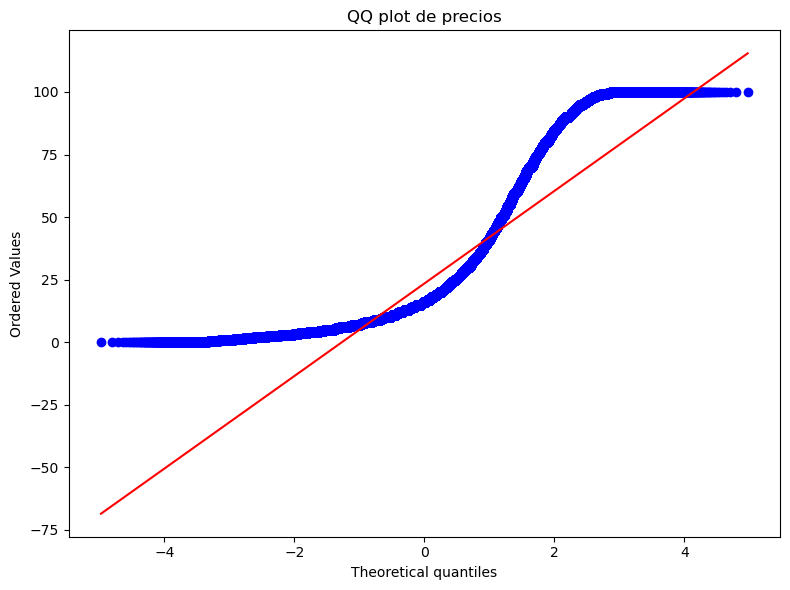

In [22]:
# - Examine if product prices typically follow a normal distribution using a QQ plot.
import scipy.stats as stats

plt.figure(figsize=(8, 6))
stats.probplot(df_sin_outliers['price'], dist="norm", plot=plt)
plt.title('QQ plot de precios')
plt.tight_layout()
plt.show()

**QQ plot de precios:**

Los precios NO siguen una distribución normal. Los puntos forman una S en vez de seguir la línea diagonal:

- Abajo a la izquierda se aplastan cerca de £0 (los precios no pueden ser negativos y hay muchísimos productos baratos)
- En el centro se acercan a la recta (precios medios)
- Arriba a la derecha se aplanan en £100 (el techo que fijamos al quitar outliers)

Esta forma de S es típica de datos sesgados a la derecha: muchos valores bajos y una cola hacia arriba. Coincide con lo visto en los violin plots.